In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
from pyfmreader import loadfile

import plotly.graph_objects as go

import plotly.graph_objects as go
import plotly.io as pio

import pandas as pd
import seaborn as sns
import sys
import math
pi = math.pi


from pyfmreader.ps_nex.parseTDMS import grab_tdms

from pyfmrheo.utils.force_curves import get_poc_RoV_method, get_poc_regulaFalsi_method, correct_tilt, correct_offset
 

In [2]:
from scipy.signal import savgol_filter

# scan from left to right, corrected deflection, and check when value becomes positive
def find_first_positive(arr):
    """
    Returns the index of the first positive value in a NumPy array.
    Returns None if no positive value is found.
    """
    arr = np.asarray(arr)
    positives = np.where(arr > 0)[0]
    return positives[0] if positives.size > 0 else None

def smooth_derivative(y, t, window_size=5):
    """
    Computes the derivative of y with respect to t, and applies a moving average for smoothing.

    Parameters:
    - y: array-like, the signal values
    - t: array-like, the time values (must be the same length as y)
    - window_size: int, the size of the moving average window (in number of points)

    Returns:
    - smoothed_derivative: numpy array of the smoothed derivative
    """
    y = np.asarray(y)
    t = np.asarray(t)
    
    # Ensure input validity
    if y.shape != t.shape:
        raise ValueError("y and t must be the same shape.")
    
    # Numerical derivative using central differences
    dy_dt = np.gradient(y, t)
    
    # Moving average smoothing (pandas handles edges nicely)
    smoothed = pd.Series(dy_dt).rolling(window=window_size, center=True, min_periods=1).mean().to_numpy()
    
    # To account for the shift in x-axis (t) due to window size, use the same rolling mean on t
    smoothed_t = pd.Series(t).rolling(window=window_size, center=True, min_periods=1).mean().to_numpy()
    
    # Return both smoothed derivative and shifted x-axis
    return smoothed, smoothed_t

def savitzky_golay_smooth(y, window_length=11, polyorder=3):
    """
    Applies Savitzky-Golay smoothing to a 1D array.

    Parameters:
    - y: array-like, the signal to smooth
    - window_length: int, length of the filter window (must be odd and >= polyorder+2)
    - polyorder: int, order of the polynomial used to fit the samples

    Returns:
    - smoothed_y: numpy array, the smoothed signal
    # """
    y = np.asarray(y)
    # Ensure window_length is odd and less than or equal to the size of y
    if window_length % 2 == 0:
        window_length += 1
    if window_length > len(y):
        window_length = len(y) if len(y) % 2 == 1 else len(y) - 1
    return savgol_filter(y, window_length=window_length, polyorder=polyorder)



In [3]:
# sys.path.append('/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmrheo-dynamo/src')
# from pyfmrheo.routines.HertzFit import doHertzFit

### Read file and parse necessary data

In [4]:
file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/03/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.31.15.19.tdms'
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/300/'

first_file, all_files = grab_tdms(directory)

print(f'number of tdms files found: {len(all_files)}')

number of tdms files found: 49


In [5]:
# Load File
filename = all_files[30]
file = loadfile(filename)
filemetadata = file.filemetadata
print(filemetadata['file_type'])
print(f'analyzing file: {filename}')

PSNEX.tdms
analyzing file: /Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/300/fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.21.22.tdms


In [6]:
# Get some of the file metadata
# closed_loop = filemetadata['z_closed_loop']
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
file_spring_constant = filemetadata['spring_const_Nbym'] #N/m
height_channel_key = filemetadata['height_channel_key']
deflection_channel_key = filemetadata['deflection_chanel_key']
# relat0ve_SR = filemetadata['relative_SR']
# final_nb_points = filemetadata['final_nb_points']   


deflection_sensitivity = file_deflection_sensitivity / 1e9 #m/V
spring_constant = file_spring_constant

# print(f"Closed loop: {closed_loop}")
print(f"Height channel: {height_channel_key}")
print(f"Deflection Sens.: {deflection_sensitivity} m/V")
print(f"Spring Constant: {spring_constant} N/m")
print(f"file_deflection_sensitivity: {file_deflection_sensitivity}")

# print (f"Relative Sampling Rate (S/s): {1/(relat0ve_SR*0.025e-6)}"
#       f" (final nb points: {final_nb_points})"  )

Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 1.69e-08 m/V
Spring Constant: 0.1 N/m
file_deflection_sensitivity: 16.9


In [7]:
# Select curve by index
curve_idx = 0
force_curve = file.getcurve(curve_idx, bool_correct_overshoot=True, z_sensor_delay=0.001)
# THIS FUCKING FUNCTIOON KEEPS RUNNING!


# Preprocess curve
force_curve.preprocess_force_curve(file_deflection_sensitivity, height_channel_key)
# # JPK files require the height signal to be shifted
# if filemetadata['file_type'] in ('jpk-force', 'jpk-force-map', 'jpk-qi-data'):
#     force_curve.shift_height()

decimation: [10 10 10]
z_sensor_delay: 0.001, bool_correct_overshoot: True 
points removed : 50
start_indices: [    0 45785 46850]
end_indices: [45785 46850 55933]
NumPnts: [45785  1065  9083]
Deflection Length: 55884, Height: 55884
0 45785
segment relative position: 45785, segment duration: 0.9157075
App
overshoot in the approach, accounted for   
removed overshoot
---------------------
46864 47928
segment relative position: 1064, segment duration: 0.021314174999999998
Con
---------------------
46850 55884
segment relative position: 9034, segment duration: 0.1816698
Ret
---------------------


In [8]:
# Get segments and indentation
segs = force_curve.get_segments()
segs = segs
ext_data = segs[0][1]
final_nb_points = filemetadata['final_nb_points']
indentation = ext_data.indentation

Adapt code for ismahens

Total length of the force curve: 54833
55897 55897


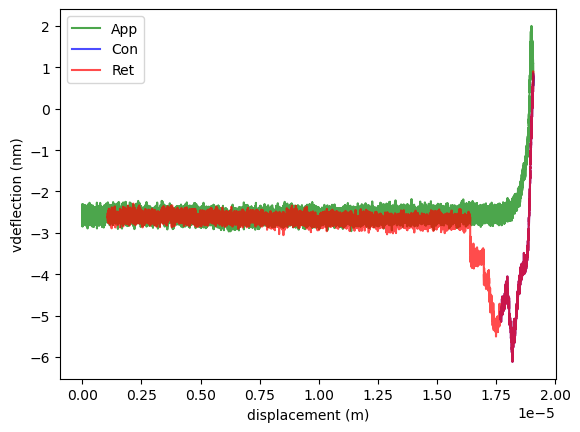

In [9]:
zmin_app = 0
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        zmin_app = segment.zheight.min()
        app_piezo = -segment.zheight
        app_deflection = -segment.vdeflection
        plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection
        plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    elif segment.segment_type in ('Contact', 'Con', 'Pause'):
        con_piezo = -segment.zheight
        con_deflection = -segment.vdeflection
        plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
plt.legend()
plt.xlabel('displacement (m)')
plt.ylabel('vdeflection (nm)')

# depening if there is a value , get length of total force curve: app+ con + ret
if 'con_piezo' in locals():
    total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)

print(f"Total length of the force curve: {total_length}")


deflection_N = np.concatenate((app_deflection, ret_deflection))
zheight = np.concatenate((app_piezo, ret_piezo)) 

print (len(zheight), len(deflection_N))

### Tilt correction
- taken from pyfmrheo

### Tilt correction Ismahene

(9034, 9034)

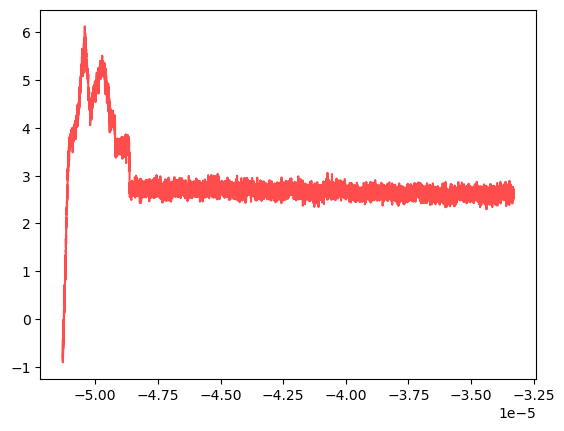

In [10]:
plt.plot(ret_piezo, ret_deflection, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
len(ret_piezo), len(ret_deflection)

In [11]:
# First do Linear fit of retract from right to left. But only take a percentage of the data
import statistics
import time as timeModule
from scipy.optimize import curve_fit  # For curve fitting
# Calculate the value :
def calc_sine(x,a,b,c,d):
    #perms of sinus: amplitude, period, phase shif, vertical shift (a,b,c,d)
    #return a * np.sin(b* ( x + np.radians(c))) + d
    return a+b*np.sin(2*pi*x/c+d)

def CorrectVirtualDeflection(deflection, distance,  Npoly, percentage,  **kwargs):
    """
    Corrects virtual deflection from the approach curve only
    the percentage is taken from the end of the approach curve

    Parameters
    ----------
    deflection_approach : numpy array
        contains the deflection data of the approach curve.
    distance : list
        contains all distance values .
    percentage : 
        DESCRIPTION.

    Returns
    -------
    corrected_deflection_approach : TYPE
        DESCRIPTION.

    """
    start_time = timeModule.time()
    
    
    #https://towardsdatascience.com/polynomial-regression-bbe8b9d97491

    dist_approach= distance

    index_end= int(len(dist_approach)*(percentage/100))

    hysteresis = kwargs.get('hysteresis', 0)

    deflection_approach= deflection

    if Npoly ==99:
        stdyp=statistics.stdev(deflection)
        distance = np.array(distance) - hysteresis

        popt, pcov = curve_fit(calc_sine, np.asarray(distance),
                      deflection_approach,
                      bounds= ([min(deflection), 0, 200, -pi*2],
                               [max(deflection), 10*stdyp, 350, pi*2]))
        corrected_deflection=  deflection - calc_sine(np.asarray(distance),*popt)
        #print(popt)
        
        #Coefficient
    else:
       # p= P.fit(dist_approach[:index_end], deflection_approach[:index_end], Npoly)
        z = np.polyfit(dist_approach[:index_end], deflection_approach[:index_end], Npoly)
        p = np.poly1d(z)    #equation
    #print('equation ', p)
        distance = np.array(distance) - hysteresis
        corrected_deflection = deflection - p(distance)

    end_time = timeModule.time()
    print('time in s CorrectVirtualDeflection : ', end_time - start_time)
    
    return  corrected_deflection #corrected_deflection_approach, corrected_deflection_retract


In [12]:
def CorrectDeflectionFromRetract(force_curve, Npoly):
    """
    Same functionality, optimized version using NumPy vectorization.
    """

    start_time = timeModule.time()
    print("Starting CorrectDeflectionFromRetract ...")

    # slices
    for segid, segment in force_curve.get_segments():
        if segment.segment_type in ('Approach', 'App'):
            dist_app = -segment.zheight
            defl_approach = -segment.vdeflection
        elif segment.segment_type in ('Retract', 'Ret'):
            dist_ret = -segment.zheight
            defl_retract = -segment.vdeflection



    deflection = np.concatenate([defl_approach, defl_retract])
    distance = np.concatenate([dist_app, dist_ret])

    print (f"length of deflection: {len(deflection)}, length of distance: {len(distance)}" )
    # Slices
    # dist_app = 
    # defl_approach = deflection[index_start_approach:index_end_approach]
    # dist_ret = distance[index_start_retract:index_end_retract]
    # defl_retract = deflection[index_start_retract:index_end_retract]

    # Compute ranges to fit
    # end_approach = int(len(dist_app) * (percentage_approach / 100))
    # start_retraction = int(len(dist_ret) * (1 - (percentage_retract / 100)))
    

    # deflection = deflection[:end_approach]  # Only take the first part of the approach curve

    # Init corrected_deflection
    # corrected_deflection = np.zeros_like(deflection)

    if Npoly == 99:
        # Sine fit case
        mean_y = statistics.mean(deflection)
        std_y = statistics.stdev(deflection)

        bounds = ([min(deflection), 0, 200, -np.pi * 2],
                  [max(deflection), 10 * std_y, 350, np.pi * 2])

        popt_approach, _ = curve_fit(calc_sine,
                                dist_app,
                                defl_approach,
                                bounds=bounds)

        popt_retraction, _ = curve_fit(calc_sine,
                                dist_ret,
                                defl_retract,
                                bounds=bounds)

        # Vectorised subtraction
        corrected_deflection_app = (defl_approach - calc_sine(dist_app, *popt_approach))
        corrected_deflection_ret = (defl_retract - calc_sine(dist_ret, *popt_retraction))
        app_correction = calc_sine(dist_app, *popt_approach)
        ret_correction = calc_sine(dist_ret, *popt_retraction)
    else:
        # Polynomfit
        pa = np.poly1d(np.polyfit(dist_app, defl_approach, Npoly))
        pr = np.poly1d(np.polyfit(dist_ret, defl_retract, Npoly))

        app_correction = pa(dist_app)
        ret_correction = pr(dist_ret)

        corrected_deflection_app = (defl_approach - pa(dist_app))
        corrected_deflection_ret = (defl_retract - pr(dist_ret))

    end_time = timeModule.time()
    print('time in s to calculate CorrectDeflectionFromRetract: ', end_time - start_time)

    return corrected_deflection_app, dist_app, corrected_deflection_ret, dist_ret, app_correction, ret_correction

In [13]:
corrected_deflection_app, dist_approach, corrected_deflection_ret, dist_retract, app_correction, ret_correction = CorrectDeflectionFromRetract(force_curve, Npoly=99)


Starting CorrectDeflectionFromRetract ...
length of deflection: 55897, length of distance: 55897
time in s to calculate CorrectDeflectionFromRetract:  0.15500497817993164


### Find contact point of retract
- take the index at which the negative deflection turns positive

In [14]:
index_first_positive = find_first_positive(corrected_deflection_ret)
print (f"Index of first positive value in corrected deflection: {index_first_positive}")

first_positive_deflection = corrected_deflection_ret[index_first_positive]
first_positive_displacement = dist_retract[index_first_positive]
print(f"First positive deflection: {first_positive_deflection}, at displacement: {first_positive_displacement}")

Index of first positive value in corrected deflection: 279
First positive deflection: 0.07332280892749887, at displacement: -5.1104793548583985e-05


In [15]:

# index_first_positive = find_first_positive(tilt_ret_deflection_N)
# print (f"Index of first positive value in corrected deflection: {index_first_positive}")

# first_positive_deflection = corrected_deflection_ret[index_first_positive]
# first_positive_displacement = dist_retract[index_first_positive]
# print(f"First positive deflection: {first_positive_deflection}, at displacement: {first_positive_displacement}")

In [16]:
ret_corrected_dispplacement = dist_retract-first_positive_displacement

In [17]:
# Find the maximum positive value in corrected_deflection_ret
positive_values = corrected_deflection_ret[corrected_deflection_ret > 0]
if positive_values.size > 0:
    max_positive_value = np.max(positive_values)
    print(f"Max positive value in corrected_deflection_ret: {max_positive_value}")
else:
    print("No positive values found in corrected_deflection_ret.")


# find the minimum 

Max positive value in corrected_deflection_ret: 3.2223696214969233


In [18]:
ret_corrected_displacement = ret_corrected_dispplacement*1e6

## need to figure out why there is a 0.3 offset...


In [19]:
corrected_deflection_ret = corrected_deflection_ret + 0.3

-0.5257135035353881


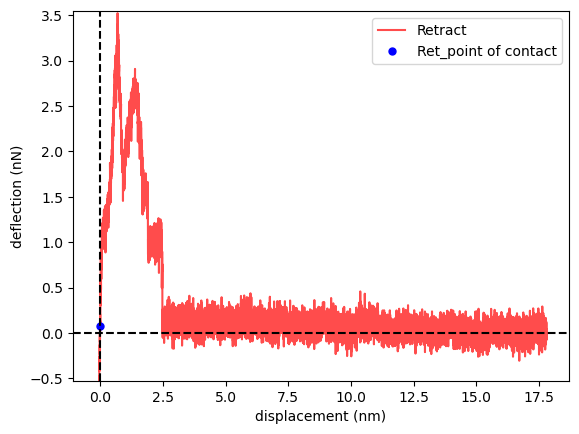

In [20]:
plt.plot(ret_corrected_displacement, corrected_deflection_ret, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #
# plt.plot(zheight-first_positive_displacement, deflection_N, color='blue', linewidth=1.5, label='Tilt Corrected Force curve')
# plt.plot(ret_corrected_dispplacement, ret_correction-2.612464904785203e-09, '--')

y_lower_limit = corrected_deflection_ret.min()*0.15 # show 10 percent from the lowest value
print(y_lower_limit)
plt.ylim(y_lower_limit ,max_positive_value*1.1)
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.ylabel('deflection (nN)')
plt.xlabel('displacement (nm)')
plt.legend()
# insert point into plot

### Do savtisky or derivative on deflection

In [21]:
# smooth_defl, smoooth_t = smooth_derivative(ret_corrected_displacement, corrected_deflection_ret, window_size=100)
# window length needs to be higher than polyorder!
savitz_defl = savitzky_golay_smooth(corrected_deflection_ret, window_length=5,polyorder=1) 

print(savitz_defl)

[-3.32861778 -3.35006642 -3.37151505 ...  0.02624581  0.01747045
  0.0086951 ]


-0.5257135035353881


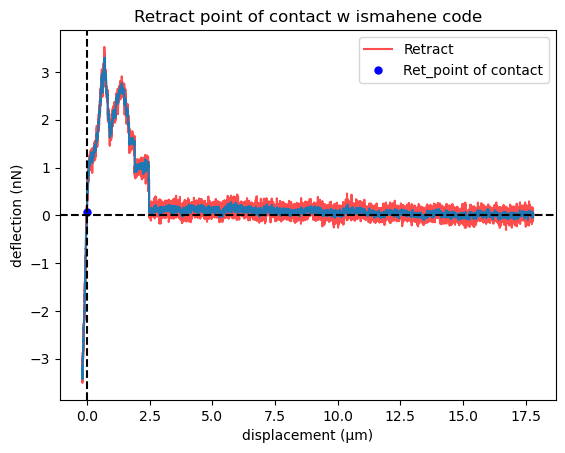

In [22]:
plt.plot(ret_corrected_displacement, corrected_deflection_ret, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(ret_corrected_displacement, savitz_defl)
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

y_lower_limit = corrected_deflection_ret.min()*0.15 # show 10 percent from the lowest value
print(y_lower_limit)
# plt.ylim(y_lower_limit ,max_positive_value*1.1)
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.ylabel('deflection (nN)')
plt.xlabel('displacement (µm)')
plt.title('Retract point of contact w ismahene code')
plt.legend()

In [23]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ret_corrected_displacement,
    y=corrected_deflection_ret,
    mode='lines',
    name='Retract',
    line=dict(color='red', width=1.5),
    opacity=0.7
))

# fig.add_trace(go.Scatter(
#     x=ret_corrected_displacement,
#     y=smooth_defl,
#     mode='lines',
#     name='Smoothed Derivative',
#     line=dict(color='blue', width=1.5, dash='dash'),
#     opacity=0.7
# ))

fig.add_trace(go.Scatter(
    x=ret_corrected_displacement,
    y=savitz_defl,
    mode='lines',
    name='savitzky',
    line=dict(color='green', width=1.5),
    opacity=0.7
))

# Add horizontal and vertical lines at y=0 and x=0
fig.add_shape(type='line',
              x0=ret_corrected_displacement.min(),
              x1=ret_corrected_displacement.max(),
              y0=0, y1=0,
              line=dict(color='black', dash='dash'))
fig.add_shape(type='line',
              x0=0, x1=0,
              y0=y_lower_limit, y1=max_positive_value*1.1,
              line=dict(color='black', dash='dash'))

fig.update_layout(
    xaxis_title='displacement (μm)',
    yaxis_title='deflection (nN)',
    legend=dict(title='Segments', bgcolor='rgba(255,255,255,0.5)', x=0.99, y=1.1),
    showlegend=True
)

fig.show()


### Now to find the peaks

x=ret_corrected_dispplacement

y=savitz_defl,

In [24]:
from scipy.signal import find_peaks

for index in range(1, 10):
    peaks, properties = find_peaks(savitz_defl,prominence=index, threshold=-0.1)
    print(f'prominence: {index}, Num of peaks found : {len(peaks)}, properties: {properties}')

prominence: 1, Num of peaks found : 2, properties: {'left_thresholds': array([0.01018278, 0.02296525]), 'right_thresholds': array([0.02404832, 0.01603248]), 'prominences': array([3.40144611, 1.13157564]), 'left_bases': array([  8, 892]), 'right_bases': array([7228, 7228])}
prominence: 2, Num of peaks found : 1, properties: {'left_thresholds': array([0.01018278]), 'right_thresholds': array([0.02404832]), 'prominences': array([3.40144611]), 'left_bases': array([8]), 'right_bases': array([7228])}
prominence: 3, Num of peaks found : 1, properties: {'left_thresholds': array([0.01018278]), 'right_thresholds': array([0.02404832]), 'prominences': array([3.40144611]), 'left_bases': array([8]), 'right_bases': array([7228])}
prominence: 4, Num of peaks found : 0, properties: {'left_thresholds': array([], dtype=float64), 'right_thresholds': array([], dtype=float64), 'prominences': array([], dtype=float64), 'left_bases': array([], dtype=int64), 'right_bases': array([], dtype=int64)}
prominence: 5, 

In [25]:
peaks, properties = find_peaks(savitz_defl, prominence=6, threshold=0 )
print (peaks)
print (properties)
# print (properties['plateau_sizes'][0])

# print (type(peaks[0]))

[]
{'left_thresholds': array([], dtype=float64), 'right_thresholds': array([], dtype=float64), 'prominences': array([], dtype=float64), 'left_bases': array([], dtype=int64), 'right_bases': array([], dtype=int64)}


### Filter the deflection with Savitsky 

-0.5257135035353881


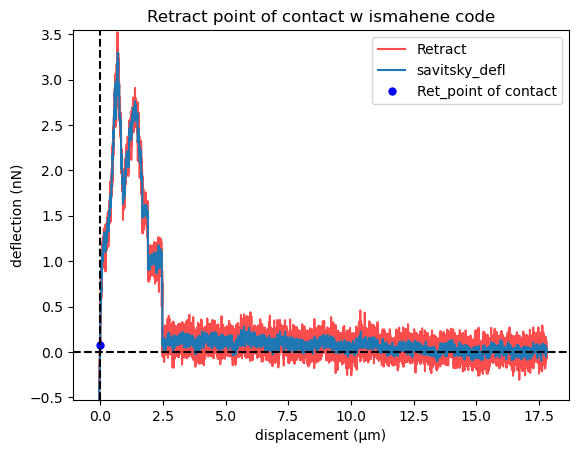

In [26]:
plt.plot(ret_corrected_displacement, corrected_deflection_ret, 'r-', linewidth=1.5, label='Retract', alpha=0.7)
plt.plot(ret_corrected_displacement, savitz_defl, label='savitsky_defl')
plt.plot(0, first_positive_deflection, 'o', color='blue', markersize=5, label='Ret_point of contact')  #

for i, peak in enumerate(peaks):
    plt.plot(ret_corrected_displacement[peak], savitz_defl[peak], 'o', label=f'peak {i}')
y_lower_limit = corrected_deflection_ret.min()*0.15 # show 10 percent from the lowest value
print(y_lower_limit)
plt.ylim(y_lower_limit ,max_positive_value*1.1)
plt.axhline(y=0, color='k', linestyle='--')
plt.axvline(x=0, color='k', linestyle='--')
plt.ylabel('deflection (nN)')
plt.xlabel('displacement (µm)')
plt.title('Retract point of contact w ismahene code')
plt.legend()

### Fine the plateaus 

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

params = {
    'threshold_pl0': 0.01,
    'min_width': 20,
    'size': 5,
    'sav_window_length': 10,
    'sav_polyorder': 1  
    

}

def find_plateaus(x, y, threshold_pl0=0.01, min_width=20, size=5):
    """
    Identify plateaus in 1D data where the first derivative is close to 0.
    
    Parameters:
        y (array): 1D signal (e.g., deflection)
        dx (float): spacing between x-values
        threshold_pl0 (float): max allowed slope for plateau of the first positive derivative
        min_width (int): minimum length (in points) of plateau
    
    Returns:
        List of tuples: (start_idx, end_idx) of plateau regions
    """
    
    dx = x[-1] - x[-2]  # Get dt of displacement by getting subtracting the time difference of the last 2 points of the array
    # print (f'dx: {dx}, dx1 {dx1}')


    # Calculate derivative of the signal, smooth it, and apply Savitzky-Golay filter
    dy = np.gradient(y, dx)
    dy_smooth = uniform_filter1d(np.abs(dy), size=size)
    dy_smooth_sav = savitzky_golay_smooth(dy_smooth, window_length=10, polyorder=1)


    # Debug Plot processed signals
    plt.plot(dy, label='dy')
    plt.plot(dy_smooth, label='dy_smooth')
    plt.plot(dy_smooth_sav, label='dy_smooth_sav')
    plt.axhline(threshold_pl0, color='r', linestyle='--', label='threshold_pl0')
    plt.title('Derivative of Signal')


    # Find peaks in the savitzky-golay smoothed signal
    peaks, properties = find_peaks(dy_smooth_sav, prominence=10, threshold=0 )
    print (peaks)
    # print (properties)
    plt.legend()
    plt.show()

    # Debug peak finder
    plt.plot(x,y, label='Signal')
    for i, peak in enumerate(peaks):
        plt.plot(x[peak], y[peak], 'o', label=f'peak {i}')
    y_lower_limit = corrected_deflection_ret.min()*0.15 # show 10 percent from the lowest value
    # print(y_lower_limit)
    plt.ylim(y_lower_limit ,max_positive_value*1.1)
    # plt.axhline(y=0, color='k', linestyle='--')
    # plt.axvline(x=0, color='k', linestyle='--')
    plt.ylabel('deflection (nN)')
    plt.xlabel('displacement (µm)')
    plt.title('Retract point of contact w ismahene code')
    plt.legend()


    is_flat = dy_smooth_sav < threshold_pl0
    plateaus = []
    start = None
    for i, flat in enumerate(is_flat):
        if flat and start is None:
            start = i
        elif not flat and start is not None:
            if i - start >= min_width:
                plateaus.append((start, i))
            start = None
    if start is not None and len(y) - start >= min_width:
        plateaus.append((start, len(y)))

    # debug plot plateaus
    plt.figure()
    plt.plot(y, label='Signal')
    for i, (start, end) in enumerate(plateaus):
        colors = plt.cm.get_cmap('tab10')
        plt.axvspan(start, end, color=colors(i % 10), alpha=0.3, label=f'Plateau{i}:{start}-{end}')
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.title('Detected Plateaus in signal')
    plt.legend(loc='upper right')
    plt.show()
    
    return plateaus

# Example usage with force curve data:
x = np.linspace(0, 10, 1000)
y = np.piecewise(x, [x < 3, (x >= 3) & (x < 6), x >= 6], [0, 5, 2]) + np.random.normal(0, 0.1, 1000)

plateaus = find_plateaus(y, dx=x[1]-x[0], threshold_pl0=50, min_width=200)
print (plateaus)

plt.plot(x, y, label='Force curve')
for i, (start, end) in enumerate(plateaus):
    plt.axvspan(x[start], x[end-1], color='green', alpha=0.3, label=f'pl{i}')
plt.legend()
plt.title("Detected Plateaus")
plt.xlabel("Displacement")
plt.ylabel("Deflection")
plt.show()

dx: 0.0
[ 235  689  767  844  890 1200 1270 1379 1522 1863 5885]


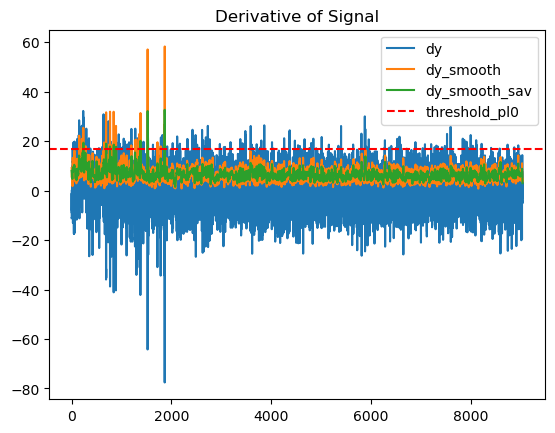

/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_5592/4198346149.py:86: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



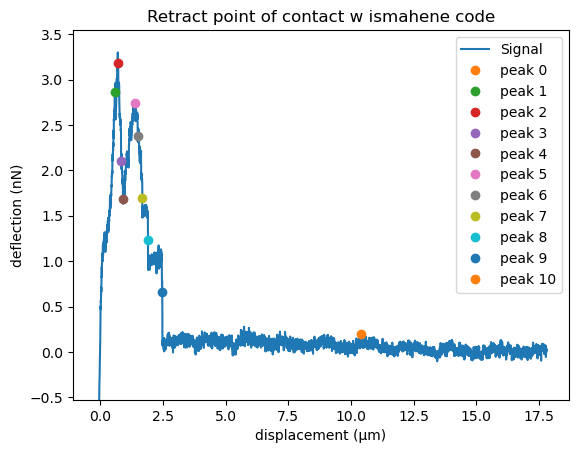

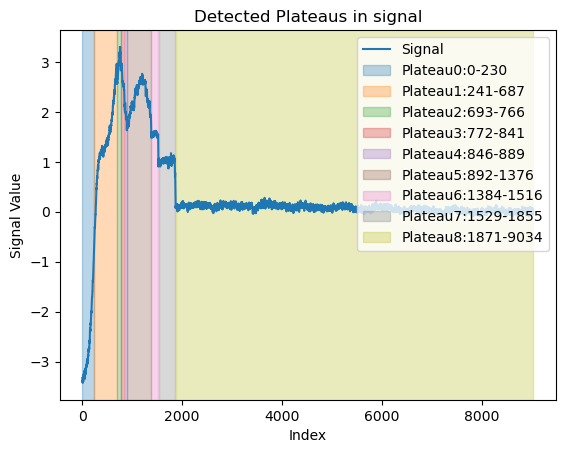

[(0, 230), (241, 687), (693, 766), (772, 841), (846, 889), (892, 1376), (1384, 1516), (1529, 1855), (1871, 9034)]


In [28]:
# Usage with real data
# start only after find the contact point from the retract

threshold_pl0 = 17
min_width = 5
dx = ret_corrected_displacement[1] - ret_corrected_displacement[0]  # Get dt of
print (f'dx: {dx}')
# defl_savitz = savitz_defl[index_first_positive:]
# displacement = ret_corrected_displacement[index_first_positive:]

defl_savitz = savitz_defl
displacement = ret_corrected_displacement
# print(displacement)
plateaus = find_plateaus(displacement, defl_savitz, threshold_pl0=threshold_pl0, min_width=min_width)
print (plateaus)

# plt.plot(displacement, defl_savitz, label='Force` curve')
# for i, (start, end) in enumerate(plateaus):
#     colors = plt.cm.get_cmap('tab10')
#     plt.axvspan(displacement[start], displacement[end-1], color=colors(i % 10), alpha=0.3, label=f'pl{i}: start{start},end{end}')
# plt.legend()
# plt.title(f"Detected Plateaus: thresh: {threshold_pl0:g}, min_width: {min_width:g}")
# plt.xlabel("Displacement (µm)")
# plt.ylabel("Deflection (nN)")
# plt.xlim(0, displacement[-1])
# plt.show()

In [29]:
# ismahene said for calculatiung the work of each unbinding event, checkout export in INterface